# pipetree quickstart

pipetree turns a declarative YAML description of a data pipeline into a dependency tree and runs it:
every table starts the moment its parents have succeeded, transient errors are retried, and a failed table
marks its descendants `upstream_failed` instead of stopping the run.

This notebook loads the example pipeline (bronze, silver and gold tables, as in the
[blog series](https://datadave.dev/tags/pipeline-engineering/)), runs it on local Spark, and then runs it
again over data with problems to show what pipetree reports for them. Run it from the `examples/` folder.

**Install** (as in the README quick start; a JDK is needed for local Spark): `uv sync --extra spark --dev`.
The package will be published on PyPI as `pipetree-meta`.

## 1. Load and validate the config

In [1]:
from pathlib import Path

from pipetree.config.loader import load_config
from pipetree.graph.builder import build_graph
from pipetree.graph.render import render_graph
from pipetree.model import PipelineConfig

config_path = Path("pipeline.yaml")
config = PipelineConfig.from_validated_raw(
    load_config(config_path)
)  # raises a ConfigError naming the bad key
print(f"{config_path}: OK")

pipeline.yaml: OK


## 2. The dependency tree

`depends_on: auto` reads the `FROM`/`JOIN` (SQL) and `spark.table(...)` (PySpark) references in each table's logic file.

In [2]:
graph = build_graph(config, base_dir=config_path.parent)
print(render_graph(graph, "text"))

bronze.customer
bronze.employee
bronze.orders
silver.customer_enriched  (depends on: bronze.customer)
gold.dim_customer  (depends on: silver.customer_enriched)
silver.orders  (depends on: bronze.orders)
gold.fact_sales  (depends on: gold.dim_customer, silver.orders)


## 3. Run it on local Spark

In [3]:
import logging

from pipetree import run_pipeline
from pipetree.adapters.spark.session import build_local_session

logging.basicConfig(level=logging.WARNING, format="%(levelname)-7s %(name)s: %(message)s")
spark = build_local_session(app_name="pipetree-quickstart", warehouse_dir="spark-warehouse")
spark.sparkContext.setLogLevel("OFF")  # keep Spark's own log lines out of the output
digest = run_pipeline(config_path, execution_id=1)

Run 1: SUCCEEDED (exit code 0)
  succeeded          bronze.customer                attempts=1 4338ms
  succeeded          bronze.employee                attempts=1 4278ms
  succeeded          bronze.orders                  attempts=1 4297ms
  succeeded          gold.dim_customer              attempts=1 2001ms
  succeeded          gold.fact_sales                attempts=1 783ms
  succeeded          silver.customer_enriched       attempts=1 1061ms
  succeeded          silver.orders                  attempts=1 1241ms


The picture below is the same run's graph. pipetree draws it as HTML (`pipetree graph --format html`, or live
with `--live-html`); GitHub does not render HTML outputs, so this notebook shows the PNG that
`examples/make_screenshots.py` makes from it.

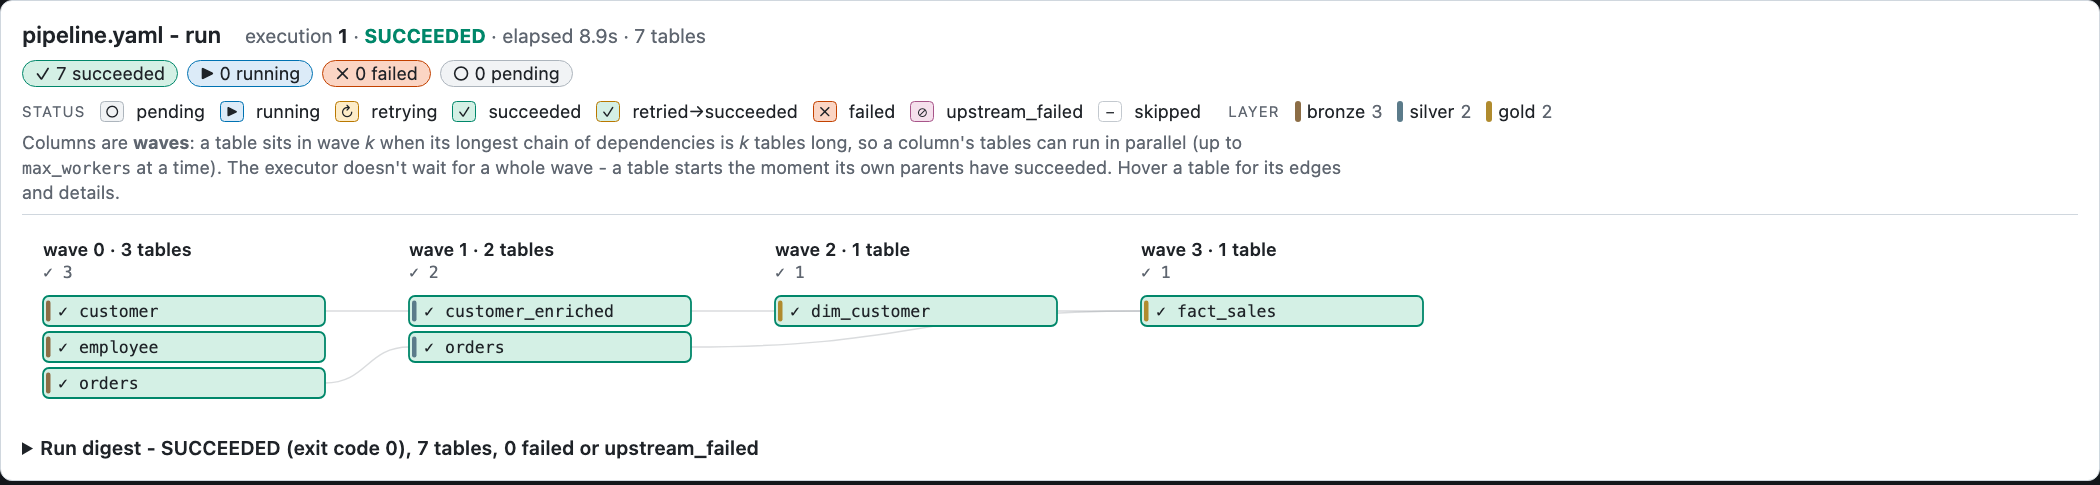

In [4]:
from IPython.display import Image

Image(filename="../docs/images/graph-clean.png", width=1000)

## 4. Read the results

In [5]:
spark.table("silver.orders").show()
spark.table("gold.dim_customer").show()

+--------+------------------+------+----------+---------------+---------------+-----------+-------------+--------------+
|order_id|customer_accountid|amount|order_date|   _inserted_at|    _updated_at|_is_deleted|_execution_id|_source_system|
+--------+------------------+------+----------+---------------+---------------+-----------+-------------+--------------+
|     101|                 1| 250.0|2026-02-01|261010105619147|261010105619147|      false|            1|          NULL|
|     102|                 2|  89.5|2026-02-02|261010105619147|261010105619147|      false|            1|          NULL|
|     103|                 1|410.25|2026-02-03|261010105619147|261010105619147|      false|            1|          NULL|
|     104|               999|  15.0|2026-02-04|261010105619147|261010105619147|      false|            1|          NULL|
+--------+------------------+------+----------+---------------+---------------+-----------+-------------+--------------+



+---------+-----------------+---------------+---------------+-----------+-------------+--------------+---------------+---------+-----------+
|accountid|             name|   _inserted_at|    _updated_at|_is_deleted|_execution_id|_source_system|    _valid_from|_valid_to|_is_current|
+---------+-----------------+---------------+---------------+-----------+-------------+--------------+---------------+---------+-----------+
|        1|      Contoso Ltd|261010105620391|261010105620391|      false|            1|          NULL|261010105620391|     NULL|       true|
|        2|     Fabrikam Inc|261010105620391|261010105620391|      false|            1|          NULL|261010105620391|     NULL|       true|
|        3|Northwind Traders|261010105620391|261010105620391|      false|            1|          NULL|261010105620391|     NULL|       true|
|       -1|             NULL|261010105621415|261010105621415|      false|            1|          NULL|261010105621415|     NULL|       true|
+---------+--

`gold.dim_customer` is an `scd2` table with `unknown_member: true`: the `-1` row is what a fact row resolves to
when its customer is missing (order 104 points at a customer that does not exist).

## 5. The same pipeline over data with problems

`examples/with_problems/` holds the same pipeline with a second delivery of the source files that contains
duplicate rows for one key, a row with a NULL key, and a new column. A merge that drops or adapts still
succeeds, so each becomes a *note* on the table (log warning, the digest's `notes:` and a `⚠` badge in the graph).
Its `gold.dim_customer` is also broken on purpose, so the run shows a failed table and an `upstream_failed` one.
See `examples/with_problems/README.md`.

In [6]:
import shutil
import tempfile

work = Path(tempfile.mkdtemp(prefix="with_problems-")) / "with_problems"
shutil.copytree("with_problems", work, ignore=shutil.ignore_patterns("__pycache__", "run.py"))

print("--- first delivery (no data problems) ---")
run_pipeline(work / "pipeline.yaml", execution_id=2)

for new in (work / "data_next").glob("*.csv"):  # the second delivery replaces the source files
    shutil.copy(new, work / "data" / new.name)

print("--- second delivery (problems) ---")
digest = run_pipeline(work / "pipeline.yaml", execution_id=3)

--- first delivery (no data problems) ---


ERROR   pipetree.executor: gold.dim_customer: failed after 1 attempt(s): AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `region` cannot be resolved. Did you mean one of the following? [`name`, `accountid`, `_execution_id`, `_inserted_at`, `_is_deleted`]. SQLSTATE: 42703; line 4 pos 24;
'Project [accountid#12978, name#12979, 'region]
+- SubqueryAlias spark_catalog.silver.customer_enriched
   +- Relation spark_catalog.silver.customer_enriched[accountid#12978,name#12979,_inserted_at#12980L,_updated_at#12981L,_is_deleted#12982,_execution_id#12983,_source_system#12984] parquet



WARNING pipetree.executor: gold.fact_sales: upstream_failed (ancestor gold.dim_customer failed)


WARNING pipetree.adapters.spark: bronze.employee: dropped 1 source row(s) with a NULL business key (employee_id) - a NULL business key cannot identify a row


WARNING pipetree.adapters.spark: bronze.customer: dropped 2 duplicate row(s) for key (accountid) - kept the highest (versionnumber)


Run 2: FAILED (exit code 1)
  succeeded          bronze.customer                attempts=1 1581ms
  succeeded          bronze.employee                attempts=1 1470ms
  succeeded          bronze.orders                  attempts=1 1470ms
  failed             gold.dim_customer              attempts=1 18ms  AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `region` cannot be resolved. Did you mean one of the following? [`name`, `accountid`, `_execution_id`, `_inserted_at`, `_is_deleted`]. SQLSTATE: 42703; line 4 pos 24;
'Project [accountid#12978, name#12979, 'region]
+- SubqueryAlias spark_catalog.silver.customer_enriched
   +- Relation spark_catalog.silver.customer_enriched[accountid#12978,name#12979,_inserted_at#12980L,_updated_at#12981L,_is_deleted#12982,_execution_id#12983,_source_system#12984] parquet

  upstream_failed    gold.fact_sales                attempts=0 0ms
  succeeded          silver.customer_enriched       attempt

ERROR   pipetree.executor: gold.dim_customer: failed after 1 attempt(s): AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `region` cannot be resolved. Did you mean one of the following? [`name`, `accountid`, `_execution_id`, `_inserted_at`, `_is_deleted`]. SQLSTATE: 42703; line 4 pos 24;
'Project [accountid#19764, name#19765, 'region]
+- SubqueryAlias spark_catalog.silver.customer_enriched
   +- Relation spark_catalog.silver.customer_enriched[accountid#19764,name#19765,_inserted_at#19766L,_updated_at#19767L,_is_deleted#19768,_execution_id#19769,_source_system#19770] parquet



WARNING pipetree.executor: gold.fact_sales: upstream_failed (ancestor gold.dim_customer failed)


Run 3: FAILED (exit code 1)
  succeeded          bronze.customer                attempts=1 1889ms  notes: 2 duplicate row(s) dropped
  succeeded          bronze.employee                attempts=1 1257ms  notes: 1 NULL-key row(s) dropped
  succeeded          bronze.orders                  attempts=1 836ms  notes: schema: added: channel (string)
  failed             gold.dim_customer              attempts=1 9ms  AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `region` cannot be resolved. Did you mean one of the following? [`name`, `accountid`, `_execution_id`, `_inserted_at`, `_is_deleted`]. SQLSTATE: 42703; line 4 pos 24;
'Project [accountid#19764, name#19765, 'region]
+- SubqueryAlias spark_catalog.silver.customer_enriched
   +- Relation spark_catalog.silver.customer_enriched[accountid#19764,name#19765,_inserted_at#19766L,_updated_at#19767L,_is_deleted#19768,_execution_id#19769,_source_system#19770] parquet

  upstream_failed  

The second run's digest lists the notes next to the tables they belong to. The graph of that run:

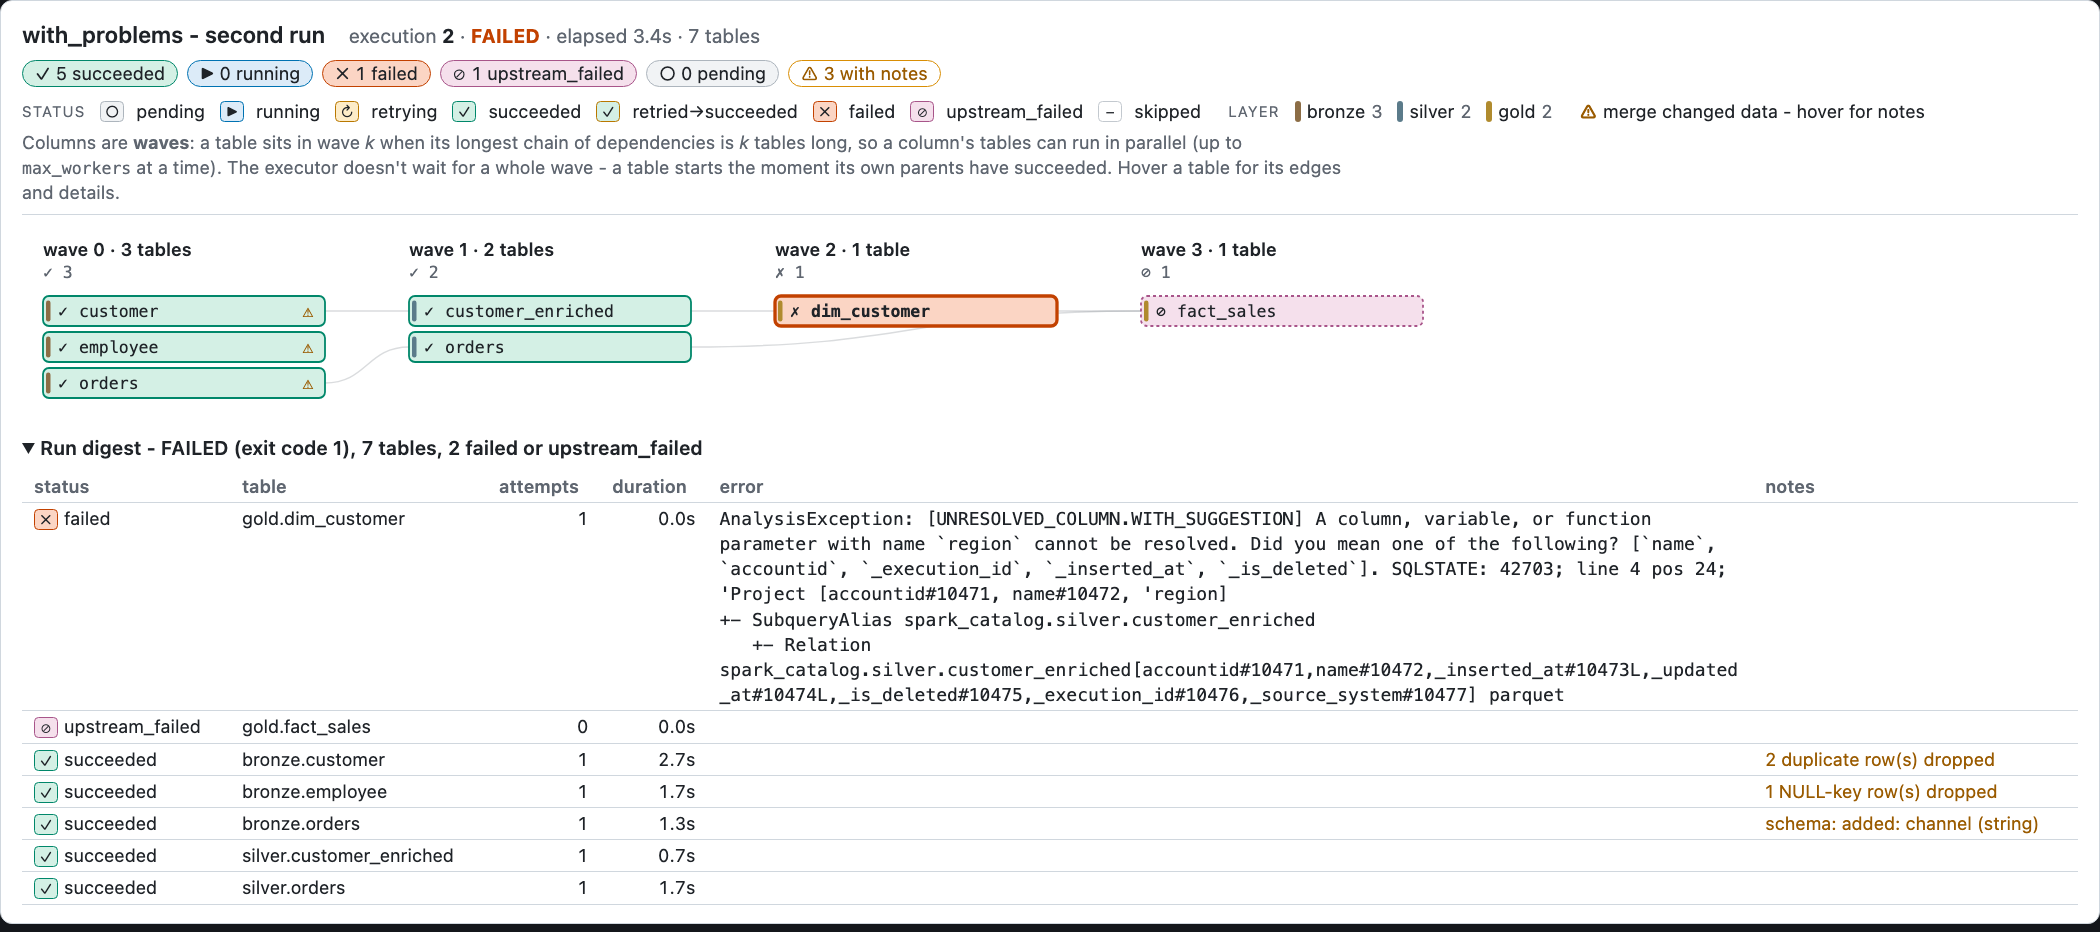

In [7]:
Image(filename="../docs/images/graph-with-notes.png", width=1000)

In [8]:
(
    spark.table("bronze.customer")
    .select("accountid", "name", "versionnumber", "_is_current")
    .orderBy("accountid", "versionnumber")
    .show()
)
spark.table("bronze.orders").show()
spark.stop()

+---------+--------------------+-------------+-----------+
|accountid|                name|versionnumber|_is_current|
+---------+--------------------+-------------+-----------+
|        1|         Contoso Ltd|            1|       true|
|        2|        Fabrikam Inc|            1|      false|
|        2|Fabrikam Incorpor...|            3|       true|
|        3|   Northwind Traders|            1|       true|
+---------+--------------------+-------------+-----------+



+--------+------------------+------+----------+---------------+---------------+-----------+-------------+--------------+-------+
|order_id|customer_accountid|amount|order_date|   _inserted_at|    _updated_at|_is_deleted|_execution_id|_source_system|channel|
+--------+------------------+------+----------+---------------+---------------+-----------+-------------+--------------+-------+
|     101|                 1| 250.0|2026-02-01|261010105616411|261010105616411|      false|            1|      erp_d365|   NULL|
|     102|                 2|  89.5|2026-02-02|261010105616411|261010105616411|      false|            1|      erp_d365|   NULL|
|     103|                 1|410.25|2026-02-03|261010105616411|261010105616411|      false|            1|      erp_d365|   NULL|
|     104|               999|  15.0|2026-02-04|261010105616411|261010105616411|      false|            1|      erp_d365|   NULL|
|     105|                 3|  72.0|2026-03-05|261010105625599|261010105625599|      false|      